# M4 — U-Net 1D Temporal (TFM)

| Parámetro | Valor |
|-----------|-------|
| Entrada X | `orientation` (45) + `acceleration` (15) → **60 features** |
| Salida y | `smpl_pose` → **135 DOF** |
| Ventana | T = 60 frames, stride = 30 |
| Arquitectura | U-Net 1D · 3 niveles · 64→128→256 · kernel=3 · BN + ReLU |
| Optimizador | Adam lr=3e-4 · CosineAnnealingLR |
| Batch / Épocas | 32 / 50 |


## 1. Entorno

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Rutas ──────────────────────────────────────────────────────────────────
DATA_DIR = '/content/drive/MyDrive/TFM_DT/DIPIMUandOthers'
CKPT_DIR = '/content/drive/MyDrive/TFM_DT/DIPIMUandOthers/checkpoints_M4'
os.makedirs(CKPT_DIR, exist_ok=True)

# ── Hiperparámetros ────────────────────────────────────────────────────────
IN_CH      = 60    # orientation(45) + acceleration(15)
OUT_CH     = 135   # smpl_pose DOF
BASE_CH    = 64    # canales base U-Net (64→128→256)
WIN        = 60    # longitud de ventana temporal
STRIDE     = 30    # solapamiento 50 %
LR         = 3e-4
BATCH_SIZE = 32
EPOCHS     = 50
SEED       = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Device: cuda


## 2. Carga de datos

In [3]:
def load_split(filename):
    """Devuelve listas de secuencias (X_seqs, y_seqs).
    Cada elemento: X (T, 60), y (T, 135)."""
    path = os.path.join(DATA_DIR, filename)
    d = np.load(path, allow_pickle=True)
    ori_list  = list(d['orientation'])   # lista de (T, 45)
    acc_list  = list(d['acceleration'])  # lista de (T, 15)
    pose_list = list(d['smpl_pose'])     # lista de (T, 135)
    X_seqs = [
        np.concatenate([o.astype(np.float32), a.astype(np.float32)], axis=1)
        for o, a in zip(ori_list, acc_list)
    ]
    y_seqs = [p.astype(np.float32) for p in pose_list]
    return X_seqs, y_seqs


def seq_info(name, seqs):
    lens = [len(s) for s in seqs]
    print(f'  {name:8s}: {len(seqs):4d} seqs  T media={np.mean(lens):.0f}  '
          f'min={min(lens)}  max={max(lens)}')


print('Cargando datos...')
X_tr_seqs, y_tr_seqs = load_split('imu_own_training.npz')
X_vl_seqs, y_vl_seqs = load_split('imu_own_validation.npz')
X_te_seqs, y_te_seqs = load_split('imu_own_test.npz')

seq_info('Train', X_tr_seqs)
seq_info('Val',   X_vl_seqs)
seq_info('Test',  X_te_seqs)
print(f'Forma muestra → X: {X_tr_seqs[0].shape}  y: {y_tr_seqs[0].shape}')

Cargando datos...
  Train   :  851 seqs  T media=296  min=103  max=300
  Val     :    3 seqs  T media=4372  min=998  max=6578
  Test    :   18 seqs  T media=2885  min=721  max=5609
Forma muestra → X: (300, 60)  y: (300, 135)


## 3. Normalización Z-score

In [4]:
# Estadísticas solo del split de entrenamiento
X_all_tr = np.concatenate(X_tr_seqs, axis=0)  # (T_total, 60)
y_all_tr = np.concatenate(y_tr_seqs, axis=0)  # (T_total, 135)

X_mean, X_std = X_all_tr.mean(0), X_all_tr.std(0) + 1e-8
y_mean, y_std = y_all_tr.mean(0), y_all_tr.std(0) + 1e-8


def norm_seqs(seqs, mean, std):
    return [(s - mean) / std for s in seqs]


def denorm_y(arr):
    return arr * y_std + y_mean


X_tr_n = norm_seqs(X_tr_seqs, X_mean, X_std)
y_tr_n = norm_seqs(y_tr_seqs, y_mean, y_std)
X_vl_n = norm_seqs(X_vl_seqs, X_mean, X_std)
y_vl_n = norm_seqs(y_vl_seqs, y_mean, y_std)
X_te_n = norm_seqs(X_te_seqs, X_mean, X_std)
y_te_n = norm_seqs(y_te_seqs, y_mean, y_std)

np.savez(os.path.join(CKPT_DIR, 'norm_stats.npz'),
         X_mean=X_mean, X_std=X_std, y_mean=y_mean, y_std=y_std)
print('Estadísticas de normalización guardadas.')

Estadísticas de normalización guardadas.


## 4. Ventanas deslizantes, Dataset y DataLoader

In [5]:
def make_windows(X_seqs, y_seqs, win=WIN, stride=STRIDE):
    """Genera ventanas de longitud `win` con paso `stride`.
    Descarta secuencias más cortas que `win`.
    Retorna arrays (N, win, C)."""
    Xs, ys = [], []
    skipped = 0
    for X, y in zip(X_seqs, y_seqs):
        T = len(X)
        if T < win:
            skipped += 1
            continue
        for start in range(0, T - win + 1, stride):
            Xs.append(X[start:start + win])
            ys.append(y[start:start + win])
    if skipped:
        print(f'  Secuencias descartadas (T < {win}): {skipped}')
    return np.stack(Xs, axis=0), np.stack(ys, axis=0)


class WindowDataset(Dataset):
    """Cada muestra: X (IN_CH, WIN), y (OUT_CH, WIN) — formato Conv1d."""
    def __init__(self, X_wins, y_wins):
        # (N, WIN, C) → (N, C, WIN)
        self.X = torch.from_numpy(X_wins.transpose(0, 2, 1))
        self.y = torch.from_numpy(y_wins.transpose(0, 2, 1))

    def __len__(self):          return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


print('Generando ventanas...')
X_tr_w, y_tr_w = make_windows(X_tr_n, y_tr_n)
X_vl_w, y_vl_w = make_windows(X_vl_n, y_vl_n)
X_te_w, y_te_w = make_windows(X_te_n, y_te_n)
print(f'  Train: {X_tr_w.shape}  Val: {X_vl_w.shape}  Test: {X_te_w.shape}')

train_loader = DataLoader(WindowDataset(X_tr_w, y_tr_w), batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(WindowDataset(X_vl_w, y_vl_w), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(WindowDataset(X_te_w, y_te_w), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Batches → train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}')

Generando ventanas...
  Train: (7543, 60, 60)  Val: (433, 60, 60)  Test: (1705, 60, 60)
Batches → train: 236  val: 14  test: 54


## 5. Arquitectura U-Net 1D

```
Entrada (B, 60, T)
  └─ enc1  Conv×2 60→64  ──────────────────────────── skip1 ─┐
      └─ pool ↓2                                              │
        └─ enc2  Conv×2 64→128  ──────────────── skip2 ─┐    │
            └─ pool ↓2                                   │    │
              └─ enc3 (bottleneck) Conv×2 128→256        │    │
                  └─ up2 ×2 256→128                      │    │
                    └─ cat + dec2  256→128  ─────────────┘    │
                        └─ up1 ×2 128→64                      │
                          └─ cat + dec1  128→64  ─────────────┘
                              └─ out Conv1×1  64→135
Salida (B, 135, T)
```

In [6]:
class DoubleConv(nn.Module):
    """Bloque Conv1d-BN-ReLU × 2."""
    def __init__(self, in_ch, out_ch, kernel=3):
        super().__init__()
        p = kernel // 2
        self.block = nn.Sequential(
            nn.Conv1d(in_ch,  out_ch, kernel, padding=p, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, kernel, padding=p, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet1D(nn.Module):
    """U-Net temporal 1D — 3 niveles encoder/decoder con skip connections.

    Input:  (B, in_ch=60,  T)  — 60 features IMU
    Output: (B, out_ch=135, T) — 135 DOF smpl_pose

    Canales: 64 → 128 → 256 (bottleneck), luego 128 → 64
    """
    def __init__(self, in_ch=IN_CH, out_ch=OUT_CH, base=BASE_CH):
        super().__init__()
        # Encoder
        self.enc1  = DoubleConv(in_ch,    base)        # (B, 64,  T)
        self.pool1 = nn.MaxPool1d(2)                    # (B, 64,  T/2)
        self.enc2  = DoubleConv(base,     base * 2)    # (B, 128, T/2)
        self.pool2 = nn.MaxPool1d(2)                    # (B, 128, T/4)
        # Bottleneck (nivel 3)
        self.enc3  = DoubleConv(base * 2, base * 4)   # (B, 256, T/4)
        # Decoder
        self.up2   = nn.ConvTranspose1d(base * 4, base * 2,
                                        kernel_size=2, stride=2)
        self.dec2  = DoubleConv(base * 4, base * 2)   # cat→256, sal→128
        self.up1   = nn.ConvTranspose1d(base * 2, base,
                                        kernel_size=2, stride=2)
        self.dec1  = DoubleConv(base * 2, base)        # cat→128, sal→64
        # Proyección de salida
        self.out   = nn.Conv1d(base, out_ch, kernel_size=1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv1d, nn.ConvTranspose1d)):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def _match(self, x, ref):
        """Ajusta la longitud temporal de x a la de ref si hay desfase de 1 px."""
        if x.size(-1) != ref.size(-1):
            x = F.interpolate(x, size=ref.size(-1), mode='nearest')
        return x

    def forward(self, x):
        # Encoder
        s1 = self.enc1(x)                       # (B, 64,  T)
        s2 = self.enc2(self.pool1(s1))          # (B, 128, T/2)
        b  = self.enc3(self.pool2(s2))          # (B, 256, T/4)
        # Decoder
        d2 = self._match(self.up2(b), s2)      # (B, 128, T/2)
        d2 = self.dec2(torch.cat([d2, s2], dim=1))   # (B, 128, T/2)
        d1 = self._match(self.up1(d2), s1)     # (B, 64,  T)
        d1 = self.dec1(torch.cat([d1, s1], dim=1))   # (B, 64,  T)
        return self.out(d1)                     # (B, 135, T)


model    = UNet1D().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nParámetros entrenables: {n_params:,}')

# Verificación de formas
with torch.no_grad():
    dummy = torch.zeros(2, IN_CH, WIN, device=DEVICE)
    out   = model(dummy)
print(f'\nPrueba de forma → entrada {tuple(dummy.shape)}  salida {tuple(out.shape)}')
assert out.shape == (2, OUT_CH, WIN), 'Error de forma en la salida'

UNet1D(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv1d(60, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): 

## 6. Entrenamiento

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history   = {'train_loss': [], 'val_loss': [], 'lr': []}
best_val  = float('inf')
best_ckpt = os.path.join(CKPT_DIR, 'M4_UNet_best.pt')


def run_epoch(loader, train):
    model.train() if train else model.eval()
    total, n = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred   = model(xb)                    # (B, 135, WIN)
            loss   = F.mse_loss(pred, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total += loss.item() * xb.size(0)
            n     += xb.size(0)
    return total / n


print(f'{"Ep":>4}  {"Train MSE":>12}  {"Val MSE":>10}  {"LR":>9}  {"s":>5}')
print('-' * 48)

for epoch in range(1, EPOCHS + 1):
    t0      = time.time()
    tr_loss = run_epoch(train_loader, train=True)
    vl_loss = run_epoch(val_loader,   train=False)
    scheduler.step()
    cur_lr  = scheduler.get_last_lr()[0]

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['lr'].append(cur_lr)

    tag = ''
    if vl_loss < best_val:
        best_val = vl_loss
        torch.save({'epoch': epoch,
                    'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(),
                    'val_loss': best_val}, best_ckpt)
        tag = '  <-- best'

    if epoch % 5 == 0 or epoch == 1:
        torch.save({'epoch': epoch,
                    'model_state': model.state_dict(),
                    'val_loss': vl_loss},
                   os.path.join(CKPT_DIR, f'M4_UNet_epoch{epoch:03d}.pt'))

    print(f'{epoch:4d}  {tr_loss:12.6f}  {vl_loss:10.6f}  '
          f'{cur_lr:9.2e}  {time.time()-t0:5.1f}{tag}')

print(f'\nEntrenamiento completado  —  mejor val_loss = {best_val:.6f}')

  Ep     Train MSE     Val MSE         LR      s
------------------------------------------------
   1      0.986653    1.293170   3.00e-04    5.6  <-- best
   2      0.643160    1.122197   2.99e-04    2.7  <-- best
   3      0.548818    1.095663   2.97e-04    2.6  <-- best
   4      0.491673    1.028670   2.95e-04    2.7  <-- best
   5      0.447477    1.042353   2.93e-04    4.0
   6      0.416750    1.030487   2.89e-04    3.1
   7      0.392970    1.000136   2.86e-04    2.7  <-- best
   8      0.371891    1.024930   2.81e-04    2.5
   9      0.357923    1.003829   2.77e-04    2.5
  10      0.341159    1.045801   2.71e-04    4.8
  11      0.330318    1.031318   2.66e-04    2.5
  12      0.317305    1.054885   2.59e-04    2.5
  13      0.310504    1.063199   2.53e-04    2.6
  14      0.300177    1.056214   2.46e-04    3.0
  15      0.294975    1.010132   2.38e-04    4.3
  16      0.287798    1.033948   2.30e-04    2.6
  17      0.280258    1.042401   2.22e-04    2.8
  18      0.274631 

## 7. Evaluación en test

In [8]:
ckpt = torch.load(best_ckpt, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f"Cargado checkpoint época {ckpt['epoch']}  val_loss={ckpt['val_loss']:.6f}")

model.eval()
preds_list, tgts_list = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds_list.append(model(xb.to(DEVICE)).cpu().numpy())
        tgts_list.append(yb.numpy())

# (N, 135, WIN) → (N, WIN, 135) → (N*WIN, 135)
preds_raw = np.concatenate(preds_list, axis=0).transpose(0, 2, 1).reshape(-1, OUT_CH)
tgts_raw  = np.concatenate(tgts_list,  axis=0).transpose(0, 2, 1).reshape(-1, OUT_CH)

# Desnormalizar al espacio original
preds   = denorm_y(preds_raw)
targets = denorm_y(tgts_raw)

# ── Métricas globales ──────────────────────────────────────────────────────
rmse_global  = float(np.sqrt(np.mean((preds - targets) ** 2)))
nrmse_global = rmse_global / (float(targets.max() - targets.min()) + 1e-8)
r2_global    = float(r2_score(targets, preds))

# ── Métricas por DOF ──────────────────────────────────────────────────────
rmse_dof  = np.sqrt(np.mean((preds - targets) ** 2, axis=0))
range_dof = (targets.max(axis=0) - targets.min(axis=0)) + 1e-8
nrmse_dof = rmse_dof / range_dof
r2_dof    = np.array([r2_score(targets[:, i], preds[:, i]) for i in range(OUT_CH)])

print('=' * 50)
print(f'  RMSE  global : {rmse_global:.6f}')
print(f'  nRMSE global : {nrmse_global:.4%}')
print(f'  R2    global : {r2_global:.6f}')
print('-' * 50)
print(f'  RMSE  / DOF  media={rmse_dof.mean():.6f}  std={rmse_dof.std():.6f}')
print(f'  nRMSE / DOF  media={nrmse_dof.mean():.4%}  std={nrmse_dof.std():.4%}')
print(f'  R2    / DOF  media={r2_dof.mean():.6f}  std={r2_dof.std():.6f}')
print('=' * 50)

np.savez(os.path.join(CKPT_DIR, 'M4_metrics.npz'),
         rmse=rmse_global, nrmse=nrmse_global, r2=r2_global,
         rmse_dof=rmse_dof, nrmse_dof=nrmse_dof, r2_dof=r2_dof)
print('Metricas guardadas.')

Cargado checkpoint época 7  val_loss=1.000136
  RMSE  global : 0.153944
  nRMSE global : 7.6972%
  R2    global : 0.237908
--------------------------------------------------
  RMSE  / DOF  media=0.130644  std=0.081428
  nRMSE / DOF  media=11.7475%  std=3.5403%
  R2    / DOF  media=0.237598  std=0.757045
Metricas guardadas.


## 8. Visualización de resultados

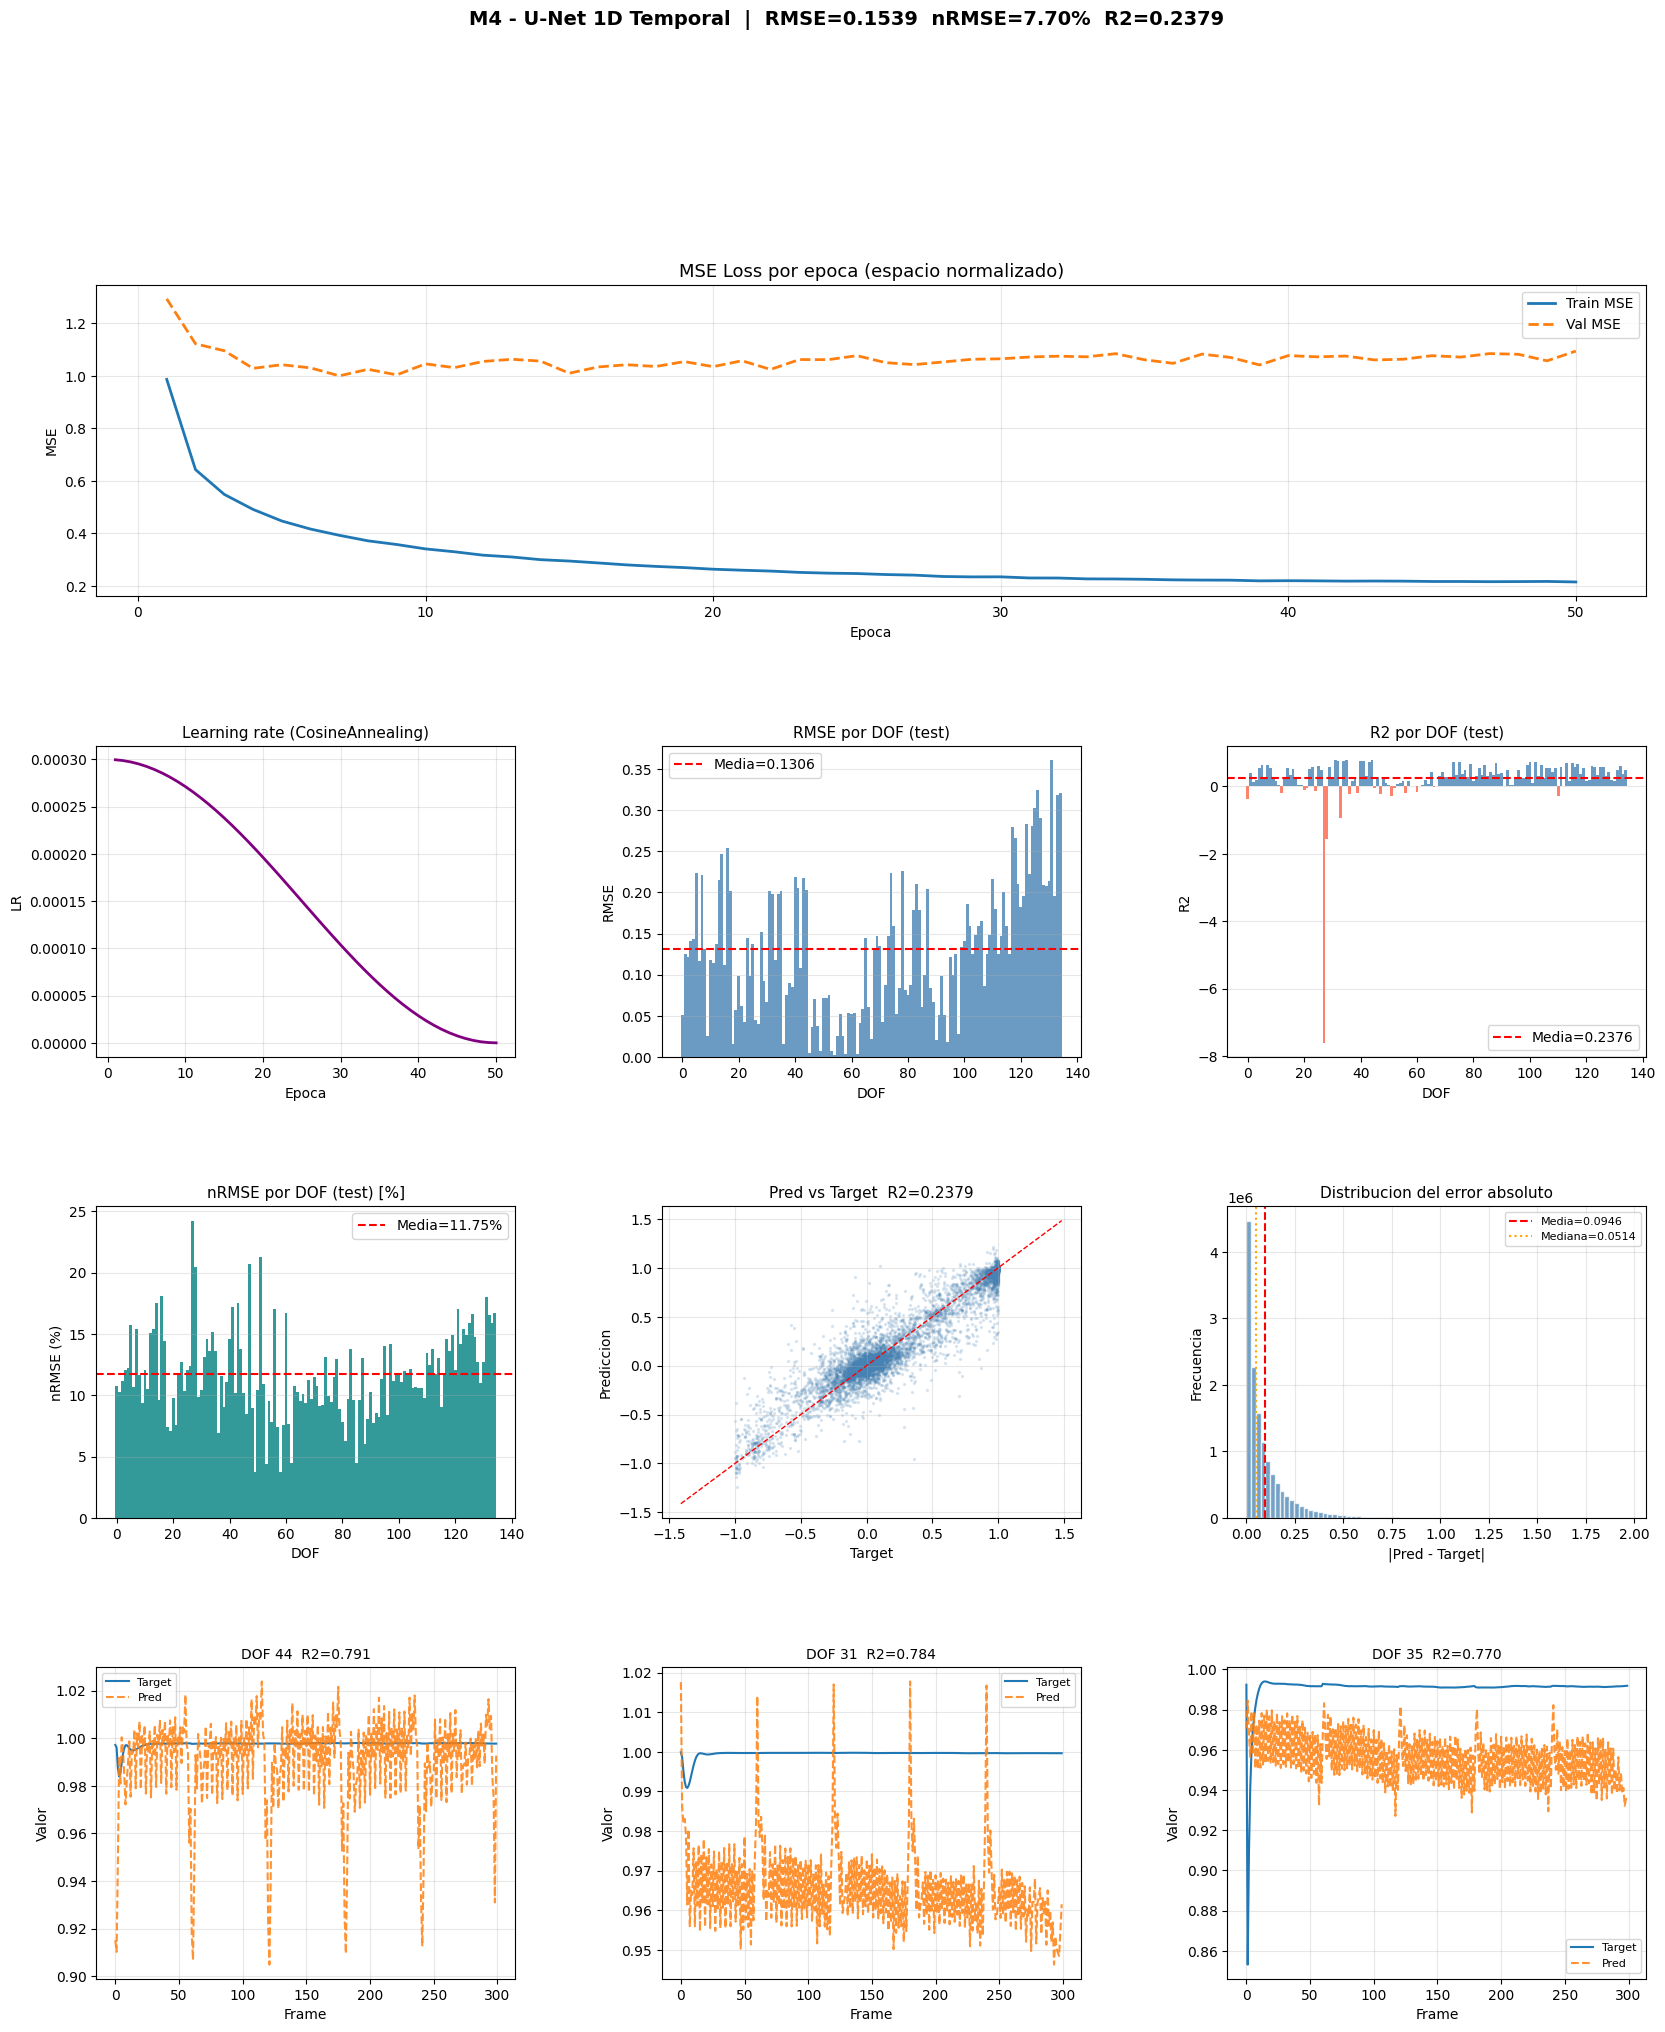

Figura guardada: /content/drive/MyDrive/TFM_DT/DIPIMUandOthers/checkpoints_M4/M4_UNet_results.png


In [9]:
ep = np.arange(1, EPOCHS + 1)

fig = plt.figure(figsize=(20, 22))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.48, wspace=0.35)

# ── A. Curvas de pérdida ───────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, :])
ax.plot(ep, history['train_loss'], lw=2,           label='Train MSE')
ax.plot(ep, history['val_loss'],   lw=2, ls='--',  label='Val MSE')
ax.set_title('MSE Loss por epoca (espacio normalizado)', fontsize=13)
ax.set_xlabel('Epoca'); ax.set_ylabel('MSE')
ax.legend(); ax.grid(alpha=0.3)

# ── B. Learning rate ──────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.plot(ep, history['lr'], color='purple', lw=2)
ax.set_title('Learning rate (CosineAnnealing)', fontsize=11)
ax.set_xlabel('Epoca'); ax.set_ylabel('LR')
ax.grid(alpha=0.3)

# ── C. RMSE por DOF ───────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.bar(np.arange(OUT_CH), rmse_dof, width=1.0, color='steelblue', alpha=0.8)
ax.axhline(rmse_dof.mean(), color='red', ls='--',
           label=f'Media={rmse_dof.mean():.4f}')
ax.set_title('RMSE por DOF (test)', fontsize=11)
ax.set_xlabel('DOF'); ax.set_ylabel('RMSE')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# ── D. R2 por DOF ─────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
col_r2 = ['steelblue' if v >= 0 else 'tomato' for v in r2_dof]
ax.bar(np.arange(OUT_CH), r2_dof, width=1.0, color=col_r2, alpha=0.8)
ax.axhline(r2_dof.mean(), color='red', ls='--',
           label=f'Media={r2_dof.mean():.4f}')
ax.set_title('R2 por DOF (test)', fontsize=11)
ax.set_xlabel('DOF'); ax.set_ylabel('R2')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# ── E. nRMSE por DOF ──────────────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
ax.bar(np.arange(OUT_CH), nrmse_dof * 100, width=1.0, color='teal', alpha=0.8)
ax.axhline(nrmse_dof.mean() * 100, color='red', ls='--',
           label=f'Media={nrmse_dof.mean()*100:.2f}%')
ax.set_title('nRMSE por DOF (test) [%]', fontsize=11)
ax.set_xlabel('DOF'); ax.set_ylabel('nRMSE (%)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# ── F. Scatter global ─────────────────────────────────────────────────────
ax  = fig.add_subplot(gs[2, 1])
rng = np.random.default_rng(0)
idx = rng.choice(preds.size, min(8000, preds.size), replace=False)
ax.scatter(targets.ravel()[idx], preds.ravel()[idx],
           alpha=0.15, s=2, color='steelblue')
lim = [min(targets.min(), preds.min()), max(targets.max(), preds.max())]
ax.plot(lim, lim, 'r--', lw=1)
ax.set_title(f'Pred vs Target  R2={r2_global:.4f}', fontsize=11)
ax.set_xlabel('Target'); ax.set_ylabel('Prediccion')
ax.grid(alpha=0.3)

# ── G. Histograma de error absoluto ───────────────────────────────────────
ax     = fig.add_subplot(gs[2, 2])
errors = np.abs(preds - targets).ravel()
ax.hist(errors, bins=80, color='steelblue', alpha=0.75, edgecolor='white')
ax.axvline(errors.mean(),     color='red',    ls='--',
           label=f'Media={errors.mean():.4f}')
ax.axvline(np.median(errors), color='orange', ls=':',
           label=f'Mediana={np.median(errors):.4f}')
ax.set_title('Distribucion del error absoluto', fontsize=11)
ax.set_xlabel('|Pred - Target|'); ax.set_ylabel('Frecuencia')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── H. Series temporales — 3 mejores DOF por R2 ───────────────────────────
top3   = np.argsort(r2_dof)[-3:][::-1]
n_show = min(300, len(targets))

for col, dof in enumerate(top3):
    ax = fig.add_subplot(gs[3, col])
    ax.plot(targets[:n_show, dof], lw=1.5,          label='Target')
    ax.plot(preds[:n_show,   dof], lw=1.5, ls='--', label='Pred', alpha=0.85)
    ax.set_title(f'DOF {dof}  R2={r2_dof[dof]:.3f}', fontsize=10)
    ax.set_xlabel('Frame'); ax.set_ylabel('Valor')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle(
    f'M4 - U-Net 1D Temporal  |  '
    f'RMSE={rmse_global:.4f}  nRMSE={nrmse_global:.2%}  R2={r2_global:.4f}',
    fontsize=14, fontweight='bold', y=1.005
)

out_fig = os.path.join(CKPT_DIR, 'M4_UNet_results.png')
fig.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {out_fig}')

## 9. Resumen

In [10]:
print('\n' + '=' * 56)
print('  RESUMEN M4 - U-NET 1D TEMPORAL')
print('=' * 56)
print(f'  Entrada  : orientation(45) + acceleration(15) = {IN_CH}')
print(f'  Salida   : smpl_pose = {OUT_CH} DOF')
print(f'  Ventana  : T={WIN}  stride={STRIDE}')
print(f'  Arq.     : U-Net 1D  {BASE_CH}->{BASE_CH*2}->{BASE_CH*4}  kernel=3  BN+ReLU')
print(f'  Params   : {n_params:,}')
print(f'  Optim.   : Adam lr={LR}  CosineAnnealingLR T_max={EPOCHS}')
print(f'  Epocas   : {EPOCHS}   Batch: {BATCH_SIZE}')
print('-' * 56)
print(f'  RMSE     : {rmse_global:.6f}')
print(f'  nRMSE    : {nrmse_global:.4%}')
print(f'  R2       : {r2_global:.6f}')
print('-' * 56)
print(f'  Ckpts    : {CKPT_DIR}')
print('=' * 56)


  RESUMEN M4 - U-NET 1D TEMPORAL
  Entrada  : orientation(45) + acceleration(15) = 60
  Salida   : smpl_pose = 135 DOF
  Ventana  : T=60  stride=30
  Arq.     : U-Net 1D  64->128->256  kernel=3  BN+ReLU
  Params   : 670,215
  Optim.   : Adam lr=0.0003  CosineAnnealingLR T_max=50
  Epocas   : 50   Batch: 32
--------------------------------------------------------
  RMSE     : 0.153944
  nRMSE    : 7.6972%
  R2       : 0.237908
--------------------------------------------------------
  Ckpts    : /content/drive/MyDrive/TFM_DT/DIPIMUandOthers/checkpoints_M4
